/Users/utsabchakraborty/Documents/Edureka_May2026/Backup_LG/venv/lib/python3.14/site-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


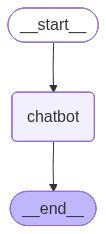

Current messages:
[HumanMessage(content='What is Agentic AI?', additional_kwargs={}, response_metadata={}, id='870911df-95bf-4929-b3b1-a1b76ac0931c')]
{'messages': [HumanMessage(content='What is Agentic AI?', additional_kwargs={}, response_metadata={}, id='870911df-95bf-4929-b3b1-a1b76ac0931c'), AIMessage(content='Agentic AI refers to artificial intelligence systems that exhibit a degree of autonomy or agency in their decision-making processes. Unlike traditional AI, which often operates under strict guidelines and requires constant human oversight, Agentic AI can analyze situations, make decisions, and take actions independently to achieve specific goals. \n\nKey features of Agentic AI include:\n\n1. **Autonomy:** The ability to operate without human intervention, making decisions based on its programming and learned experiences.\n\n2. **Goal-Oriented Behavior:** It works toward achieving predefined goals or objectives by evaluating various options and consequences.\n\n3. **Adaptabili

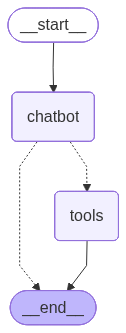


FINAL MESSAGES
================================ Human Message =================================

What is 50 plus 20?
================================== Ai Message ==================================
Tool Calls:
  my_add (call_UOsO3cTLeHlyWtT2u7hEk6mW)
 Call ID: call_UOsO3cTLeHlyWtT2u7hEk6mW
  Args:
    a: 50
    b: 20
================================= Tool Message =================================
Name: my_add

70

STREAMING TOOL EXECUTION
{'chatbot': {'messages': [AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 18, 'prompt_tokens': 62, 'total_tokens': 80, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_29ce089943', 'id': 'chatcmpl-DdwSJfMrvkNS88gwCwpBPw84YPyWU', 'service_

In [1]:
"""
=============================================================
FILE 2 — LLM NODES AND BASIC TOOL CALLING
=============================================================

CONCEPTS TAUGHT:
-----------------
1. Message-based state
2. Reducers
3. add_messages reducer
4. LLM as a node
5. Tool definitions
6. Tool binding
7. ToolNode
8. tools_condition
9. AIMessage / HumanMessage flow
10. Single tool execution
11. Structured tool calls
12. Streaming responses

KEY IDEA:
---------
LLMs can decide whether tools should be called.

"""

# =============================================================
# STEP 1 — LOAD ENV VARIABLES
# =============================================================

import os
from dotenv import load_dotenv

load_dotenv()

os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")
os.environ["LANGCHAIN_API_KEY"] = os.getenv("LANGCHAIN_API_KEY")
os.environ["LANGCHAIN_TRACING_V2"] = "true"

# =============================================================
# STEP 2 — CREATE LLM
# =============================================================

from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4o-mini")


# =============================================================
# STEP 3 — DEFINE STATE
# =============================================================
# Reducers define HOW state updates are merged.
#
# add_messages automatically appends messages
# instead of replacing them.

from typing_extensions import TypedDict
from typing import Annotated
from langgraph.graph.message import add_messages


class State(TypedDict):
    messages: Annotated[list, add_messages]

# =============================================================
# STEP 4 — BASIC CHATBOT NODE
# =============================================================
# The LLM receives all conversation messages.
# It returns an AIMessage.


def chatbot(state: State):

    print("Current messages:")
    print(state["messages"])

    response = llm.invoke(state["messages"])

    return {
        "messages": [response]
    }

# =============================================================
# STEP 5 — BUILD BASIC CHATBOT GRAPH
# =============================================================

from langgraph.graph import StateGraph, START, END

workflow = StateGraph(State)

workflow.add_node("chatbot", chatbot)

workflow.add_edge(START, "chatbot")
workflow.add_edge("chatbot", END)

app = workflow.compile()


# =============================================================
# STEP 6 — VISUALIZE GRAPH
# =============================================================

from IPython.display import Image, display


display(Image(app.get_graph().draw_mermaid_png()))

# =============================================================
# STEP 7 — TEST CHATBOT
# =============================================================

from langchain_core.messages import HumanMessage

response = app.invoke(
    {
        "messages": [
            HumanMessage(content="What is Agentic AI?")
        ]
    }
)

print(response)

# =============================================================
# STEP 8 — DEFINE TOOLS
# =============================================================
# Tools are Python functions exposed to the LLM.
#
# IMPORTANT:
# Tool docstrings help the LLM understand:
# - What the tool does
# - When to use it


def my_add(a: int, b: int) -> int:
    """
    Add two integers together.

    Use this tool whenever the user asks for addition.
    """

    return a + b

# =============================================================
# STEP 9 — BIND TOOLS TO LLM
# =============================================================
# bind_tools() tells the LLM:
# "These tools are available for use"

llm_with_tools = llm.bind_tools([my_add])

tools = [my_add]

# =============================================================
# STEP 10 — TOOL ENABLED NODE
# =============================================================
# The LLM may now return:
# - Normal text
# - Tool calls


def tool_enabled_chatbot(state: State):

    response = llm_with_tools.invoke(state["messages"])

    return {
        "messages": [response]
    }

# =============================================================
# STEP 11 — TOOL NODE
# =============================================================
# ToolNode executes tool calls generated by the LLM.

from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

workflow = StateGraph(State)

workflow.add_node("chatbot", tool_enabled_chatbot)
workflow.add_node("tools", ToolNode(tools))

workflow.add_edge(START, "chatbot")

# =============================================================
# STEP 12 — CONDITIONAL TOOL ROUTING
# =============================================================
# tools_condition checks whether the AIMessage
# contains tool calls.
#
# If tool calls exist:
# chatbot -> tools
#
# Otherwise:
# chatbot -> END

workflow.add_conditional_edges(
    "chatbot",
    tools_condition,
)

# =============================================================
# STEP 13 — SINGLE TOOL EXECUTION
# =============================================================
# This graph supports ONE tool execution only.
#
# Later files will implement iterative loops.

workflow.add_edge("tools", END)

app = workflow.compile()


display(Image(app.get_graph().draw_mermaid_png()))

# =============================================================
# STEP 14 — TEST TOOL CALLING
# =============================================================

result = app.invoke(
    {
        "messages": [
            HumanMessage(content="What is 50 plus 20?")
        ]
    }
)


print("\nFINAL MESSAGES")

for m in result["messages"]:
    m.pretty_print()

# =============================================================
# STEP 15 — STREAM EXECUTION
# =============================================================

print("\nSTREAMING TOOL EXECUTION")

for event in app.stream(
    {
        "messages": [
            HumanMessage(content="Add 100 and 500")
        ]
    }
):
    print(event)
